# Customer Segmentation using K-Means Clustering
# AI/ML Internship Project – PlaceMantra (AICTE & MSME)

Objective:
To segment customers based on their annual income and spending score
using K-Means clustering.

Dataset:
Mall Customers Dataset

Steps:
1. Data Loading
2. Feature Selection
3. Finding Optimal Clusters (Elbow Method)
4. Model Training
5. Visualization


In [ ]:
# Import required libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [ ]:
#Load Dataset
dataset=pd.read_csv("Mall_Customers_details.csv")
dataset

,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100)
0,1,Male,50,153,100
1,2,Female,36,161,58
2,3,Male,50,195,81
3,4,Male,48,161,89
4,5,Male,21,195,75
...,...,...,...,...,...
245,246,Female,22,152,58
246,247,Male,50,155,28
247,248,Male,67,38,27
248,249,Female,27,138,1


In [ ]:
# Display first 5 rows
dataset.head()

,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100)
0,1,Male,50,153,100
1,2,Female,36,161,58
2,3,Male,50,195,81
3,4,Male,48,161,89
4,5,Male,21,195,75


##Dataset Overview
This dataset contains customer details such as:
- Age
- Annual Income
- Spending Score

In [ ]:
# Selecting relevant features (Annual Income & Spending Score)
x=dataset.iloc[:, [3,4]].values
x

array([[153, 100],
       [161,  58],
       [195,  81],
       [161,  89],
       [195,  75],
       [110,  59],
       [178,  31],
       [170,  76],
       [195,  25],
       [134,  90],
       [193,  39],
       [104,  56],
       [ 24,  77],
       [ 74,  30],
       [122,   3],
       [149,  31],
       [172,  85],
       [ 46,  46],
       [ 39,  35],
       [ 20,  93],
       [197,  13],
       [ 41,  30],
       [ 11,  70],
       [147,  11],
       [133,  11],
       [183,  68],
       [ 31,  22],
       [ 82,  98],
       [127,  94],
       [ 64,  69],
       [196,  31],
       [ 39,  92],
       [190,  31],
       [ 98,  87],
       [ 30,   3],
       [ 91,  35],
       [ 29,  85],
       [122,  60],
       [176,  85],
       [ 44,  10],
       [ 38,  76],
       [119,  27],
       [ 65,  12],
       [125,  87],
       [192,  86],
       [190,  87],
       [185,  87],
       [ 76,  15],
       [192,  26],
       [ 41,  28],
       [ 67,  13],
       [ 87,  99],
       [ 78,

##Feature Selection
**I** use:
- Annual Income
- Spending Score

# Elbow Method


In [ ]:
# Finding optimal number of clusters using Elbow Method
from sklearn.cluster import KMeans
WCSS=[]
for i in range(2,11):
    kmeans=KMeans(n_clusters=i,random_state=42)
    kmeans.fit(x)
    WCSS.append(kmeans.inertia_)

##Elbow Method
Used to determine optimal number of clusters.

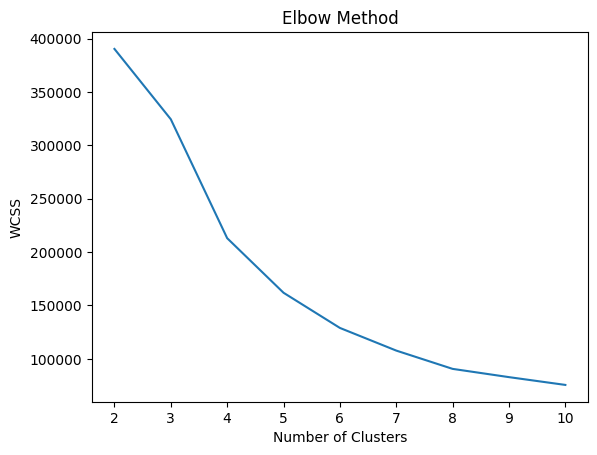

In [ ]:
plt.plot(range(2,11), WCSS)
plt.title("Elbow Method")
plt.xlabel("Number of Clusters")
plt.ylabel("WCSS")
plt.show()

In [ ]:
# Applying K-Means with optimal clusters (k=5)
kmeans=KMeans(n_clusters=5,init="k-means++",random_state=42)
y_means=kmeans.fit_predict(x)
y_means

array([1, 1, 1, 1, 1, 4, 3, 1, 3, 4, 1, 4, 2, 0, 3, 3, 1, 0, 0, 2, 3, 0,
       2, 3, 3, 1, 0, 4, 4, 2, 3, 2, 3, 4, 0, 0, 2, 4, 1, 0, 2, 3, 0, 4,
       1, 1, 1, 0, 3, 0, 0, 4, 0, 0, 0, 4, 0, 0, 2, 1, 0, 2, 4, 2, 2, 2,
       3, 0, 0, 1, 3, 3, 3, 1, 0, 0, 0, 4, 0, 2, 2, 2, 1, 3, 1, 2, 4, 4,
       4, 2, 4, 3, 4, 0, 1, 0, 4, 0, 0, 1, 3, 0, 2, 0, 0, 1, 0, 4, 2, 0,
       4, 1, 3, 0, 0, 3, 1, 1, 3, 4, 4, 3, 0, 2, 2, 2, 4, 3, 4, 3, 2, 0,
       3, 3, 3, 3, 2, 2, 2, 0, 0, 4, 3, 0, 0, 0, 1, 3, 3, 1, 2, 3, 4, 0,
       0, 0, 3, 0, 0, 1, 2, 2, 2, 0, 1, 3, 1, 3, 4, 2, 3, 1, 1, 3, 4, 3,
       2, 2, 4, 0, 4, 0, 0, 1, 3, 3, 1, 2, 1, 0, 3, 3, 2, 3, 4, 3, 4, 2,
       3, 4, 1, 1, 2, 0, 2, 2, 1, 2, 4, 3, 0, 3, 3, 4, 1, 4, 2, 3, 3, 1,
       0, 3, 0, 0, 0, 1, 2, 2, 3, 4, 3, 0, 1, 1, 0, 0, 2, 0, 3, 1, 2, 4,
       2, 0, 0, 1, 3, 0, 3, 3], dtype=int32)

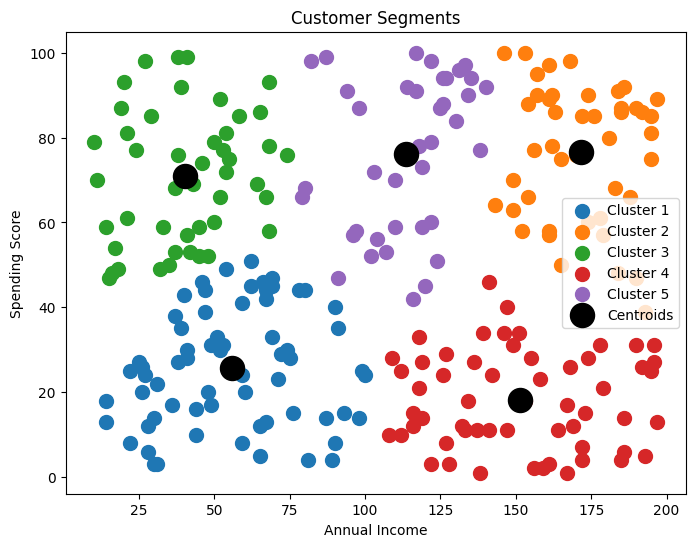

In [ ]:
# Visualizing clusters
plt.figure(figsize=(8,6))

plt.scatter(x[y_means == 0, 0], x[y_means == 0, 1], s=100, label='Cluster 1')
plt.scatter(x[y_means == 1, 0], x[y_means == 1, 1], s=100, label='Cluster 2')
plt.scatter(x[y_means == 2, 0], x[y_means == 2, 1], s=100, label='Cluster 3')
plt.scatter(x[y_means == 3, 0], x[y_means == 3, 1], s=100, label='Cluster 4')
plt.scatter(x[y_means == 4, 0], x[y_means == 4, 1], s=100, label='Cluster 5')

# Centroids
plt.scatter(kmeans.cluster_centers_[:, 0],
            kmeans.cluster_centers_[:, 1],
            s=300, c='black', label='Centroids')

plt.title("Customer Segments")
plt.xlabel("Annual Income")
plt.ylabel("Spending Score")
plt.legend()
plt.show()

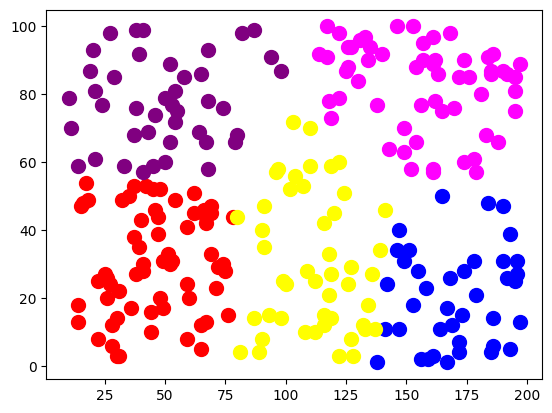

In [ ]:
plt.scatter(x[y_means==0,0],x[y_means==0,1],s=100,c="red",label='cluster 1')
plt.scatter(x[y_means==1,0],x[y_means==1,1],s=100,c="blue",label='cluster 2')
plt.scatter(x[y_means==2,0],x[y_means==2,1],s=100,c="purple",label='cluster 3')
plt.scatter(x[y_means==3,0],x[y_means==3,1],s=100,c="magenta",label='cluster 4')
plt.scatter(x[y_means==4,0],x[y_means==4,1],s=100,c="yellow",label='cluster 5')

Conclusion:
- Customers are segmented into 5 groups
- Helps businesses target specific customer groups
- Useful for marketing strategies

Future Work:
- Try DBSCAN or Hierarchical Clustering
- Use more features for better segmentation